In [1]:
import pandas as pd
import numpy as np
import pickle, os
from matplotlib import pyplot as plt
from tqdm import tqdm


In [2]:
def load_convergence_data(filename):
    """Load convergence data from pickle file"""
    with open(filename, 'rb') as f:
        data = pickle.load(f)
    
    print("Loaded data summary:")
   # print(f"  Timestamp: {data['metadata']['timestamp']}")
    print(f"  Number of walkers: {data['metadata']['n_walkers']}")
    print(f"  Total frames per walker: {data['metadata']['walker_frame_counts']}")
    print(f"  Parameters: {data['metadata']['parameters']}")
    
    return data

def plot_convergence_from_data(data, show_individual_walkers=False, states_to_plot=None):
    """Generate convergence plots from loaded data"""
    
    # Extract data
    averaged_conv = data['averaged_convergence']
    individual_conv = data.get('individual_walker_convergence', {})
    state_labels = data['metadata']['state_labels']
    dt = data['metadata']['parameters']['dt']
    
    # Convert to time
    time_ps = [frame * dt for frame in averaged_conv['frames']]
    
    if states_to_plot is None:
        states_to_plot = range(1, 9)
    
    # Create figure
    if show_individual_walkers and individual_conv:
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))
    else:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(states_to_plot)))
    
    # Plot averaged population convergence
    for i, state in enumerate(states_to_plot):
        pops = averaged_conv['populations'][state]
        errors = averaged_conv['pop_std'][state]
        
        ax1.plot(time_ps, pops, label=f'{state_labels[state]}', 
                color=colors[i], linewidth=2)
        ax1.fill_between(time_ps, 
                         [p - e for p, e in zip(pops, errors)],
                         [p + e for p, e in zip(pops, errors)],
                         color=colors[i], alpha=0.3)
    
    ax1.set_xlabel('Time (ns)')
    ax1.set_ylabel('Population')
    ax1.set_title('Population Convergence (Averaged Across Walkers)')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1)
    
    # Plot averaged free energy convergence
    for i, state in enumerate(states_to_plot):
        fes = [fe if fe != np.inf else np.nan for fe in averaged_conv['free_energies'][state]]
        errors = averaged_conv['fe_std'][state]
        
        ax2.plot(time_ps, fes, label=f'{state_labels[state]}', 
                color=colors[i], linewidth=2)
        ax2.fill_between(time_ps,
                         [f - e if not np.isnan(f) else f for f, e in zip(fes, errors)],
                         [f + e if not np.isnan(f) else f for f, e in zip(fes, errors)],
                         color=colors[i], alpha=0.3)
    
    ax2.set_xlabel('Time (ns)')
    ax2.set_ylabel('Relative Free Energy (kcal/mol)')
    ax2.set_title('Free Energy Convergence (Averaged Across Walkers)')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # Plot individual walkers if requested
    if show_individual_walkers and individual_conv:
        # Individual population trajectories
        for walker_id in individual_conv:
            conv_data = individual_conv[walker_id]
            time_ps_walker = [frame * dt for frame in conv_data['frames']]
            
            for i, state in enumerate(states_to_plot):
                pops = conv_data['populations'][state]
                ax3.plot(time_ps_walker, pops, alpha=0.6, color=colors[i])
        
        # Plot average on top
        for i, state in enumerate(states_to_plot):
            pops = averaged_conv['populations'][state]
            ax3.plot(time_ps, pops, color=colors[i], linewidth=3, 
                    label=f'{state_labels[state]}')
        
        ax3.set_xlabel('Time (ns)')
        ax3.set_ylabel('Population')
        ax3.set_title('Individual Walker Trajectories (Population)')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        
        # Individual free energy trajectories
        for walker_id in individual_conv:
            conv_data = individual_conv[walker_id]
            time_ps_walker = [frame * dt for frame in conv_data['frames']]
            
            for i, state in enumerate(states_to_plot):
                fes = [fe if fe != np.inf else np.nan for fe in conv_data['free_energies'][state]]
                ax4.plot(time_ps_walker, fes, alpha=0.6, color=colors[i])
        
        # Plot average on top
        for i, state in enumerate(states_to_plot):
            fes = [fe if fe != np.inf else np.nan for fe in averaged_conv['free_energies'][state]]
            ax4.plot(time_ps, fes, color=colors[i], linewidth=3,
                    label=f'{state_labels[state]}')
        
        ax4.set_xlabel('Time (ns)')
        ax4.set_ylabel('Relative Free Energy (kcal/mol)')
        ax4.set_title('Individual Walker Trajectories (Free Energy)')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

def print_final_results_from_data(data):
    """Print final convergence results from loaded data"""
    averaged_conv = data['averaged_convergence']
    state_labels = data['metadata']['state_labels']
    
#     print(f"\nFinal results from {data['metadata']['timestamp']}:")
    print("="*60)
    
    for state in range(1, 9):
        final_pop = averaged_conv['populations'][state][-1]
        final_pop_std = averaged_conv['pop_std'][state][-1]
        final_fe = averaged_conv['free_energies'][state][-1]
        final_fe_std = averaged_conv['fe_std'][state][-1]
        
        if final_fe != np.inf:
            print(f"{state_labels[state]}: P = {final_pop:.4f} ± {final_pop_std:.4f}, "
                  f"ΔG = {final_fe:.2f} ± {final_fe_std:.2f} kcal/mol")
        else:
            print(f"{state_labels[state]}: P = {final_pop:.4f} ± {final_pop_std:.4f}, "
                  f"ΔG = ∞ kcal/mol (not observed)")
    
    # Find reference state
    finite_states = {s: averaged_conv['free_energies'][s][-1] 
                    for s in range(1, 9) 
                    if averaged_conv['free_energies'][s][-1] != np.inf}
    
    if finite_states:
        ref_state = min(finite_states, key=finite_states.get)
        print(f"\nReference state (ΔG = 0): {state_labels[ref_state]}")

Loaded data summary:
  Number of walkers: 8
  Total frames per walker: {1: 207776, 2: 207776, 3: 207776, 4: 207776, 5: 207776, 6: 207776, 7: 207776, 8: 207776}
  Parameters: {'window_size': 1000, 'dt': 0.002, 'temperature': 2.5, 'normalization': 'minimum'}


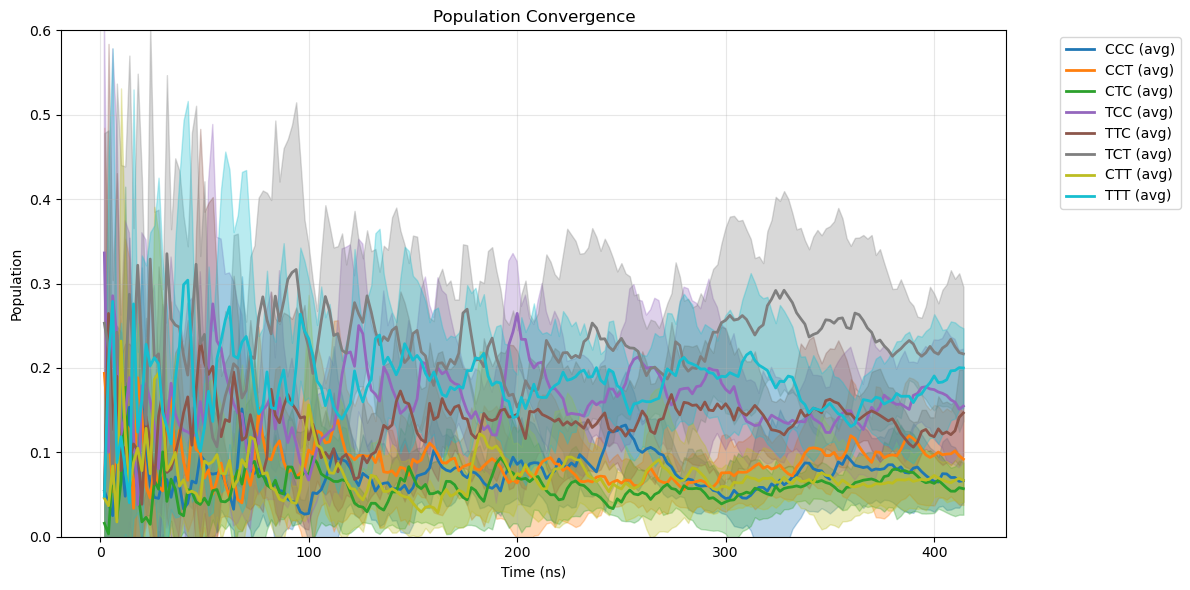

In [3]:
# Later, load and plot
oppc8rep_meta_data = load_convergence_data("convergence_data/8omg_metadynamics_convergence.pkl")

# Extract data
averaged_conv = oppc8rep_meta_data['averaged_convergence']
individual_conv = oppc8rep_meta_data.get('individual_walker_convergence', {})
state_labels = oppc8rep_meta_data['metadata']['state_labels']
dt = oppc8rep_meta_data['metadata']['parameters']['dt']

# Convert to time
time_ps = [frame * dt for frame in averaged_conv['frames']]
states_to_plot = range(1, 9)

colors = plt.cm.tab10(np.linspace(0, 1, len(states_to_plot)))

plt.figure(figsize=(12, 6))

for i, state in enumerate(states_to_plot):
    pops = averaged_conv['populations'][state]
    errors = averaged_conv['pop_std'][state]

    plt.plot(time_ps, pops, label=f'{state_labels[state]} (avg)',
             color=colors[i], linewidth=2)
    plt.fill_between(time_ps,
                     [p - e for p, e in zip(pops, errors)],
                     [p + e for p, e in zip(pops, errors)],
                     color=colors[i], alpha=0.3)

plt.xlabel('Time (ns)')
plt.ylabel('Population')
plt.title('Population Convergence')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.ylim(0, 0.6)

plt.tight_layout()
plt.show()


Loaded data summary:
  Number of walkers: 8
  Total frames per walker: {1: 205058, 2: 205058, 3: 205058, 4: 205058, 5: 205058, 6: 205058, 7: 205058, 8: 205058}
  Parameters: {'window_size': 1000, 'dt': 0.002, 'temperature': 2.5, 'normalization': 'minimum'}


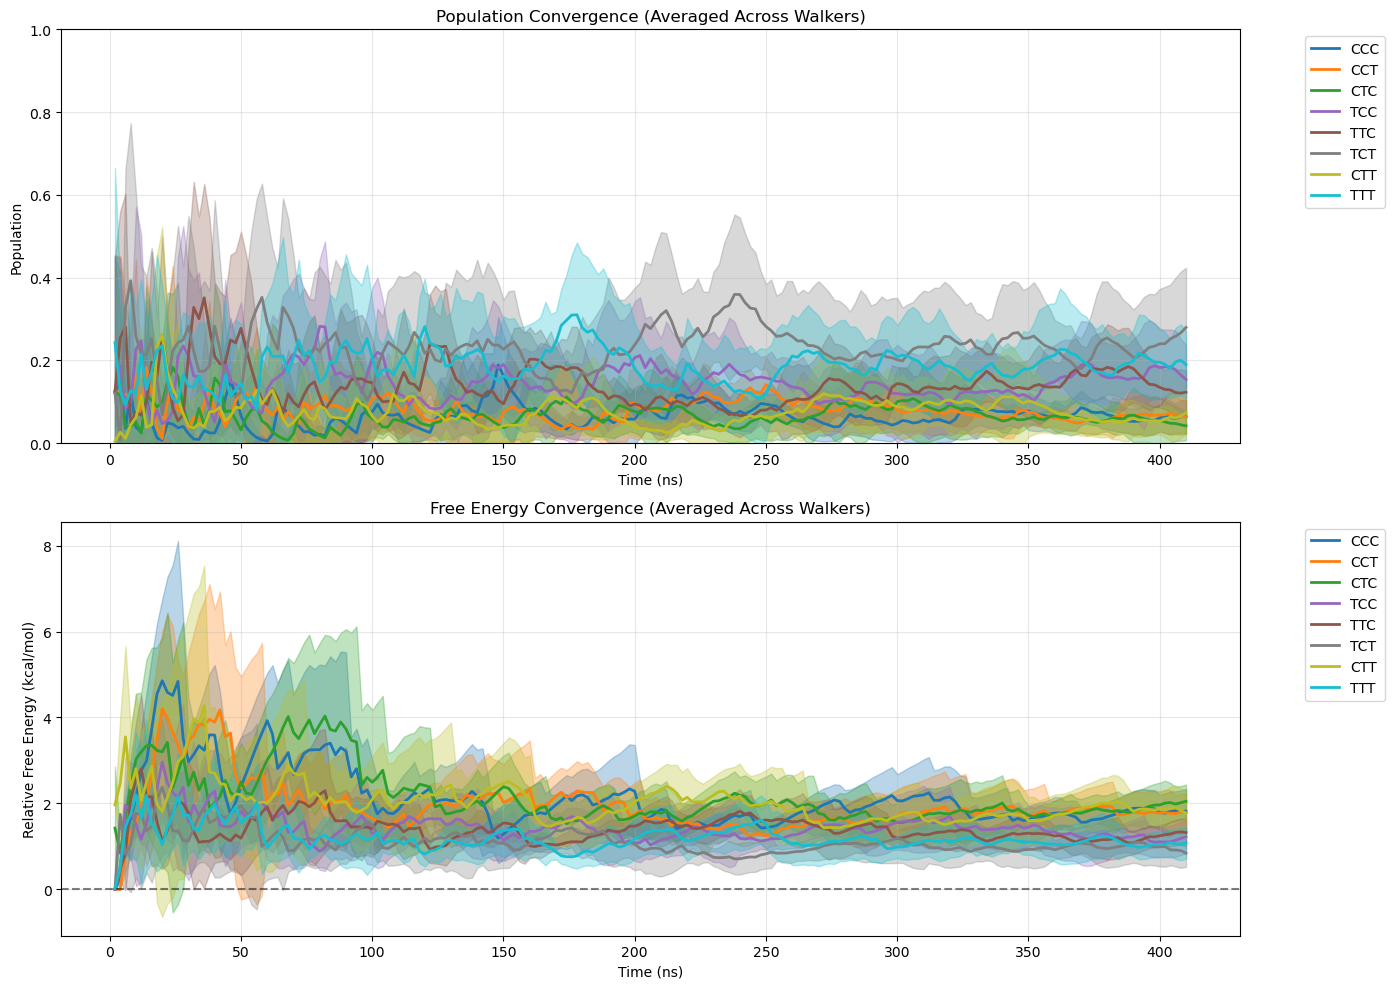

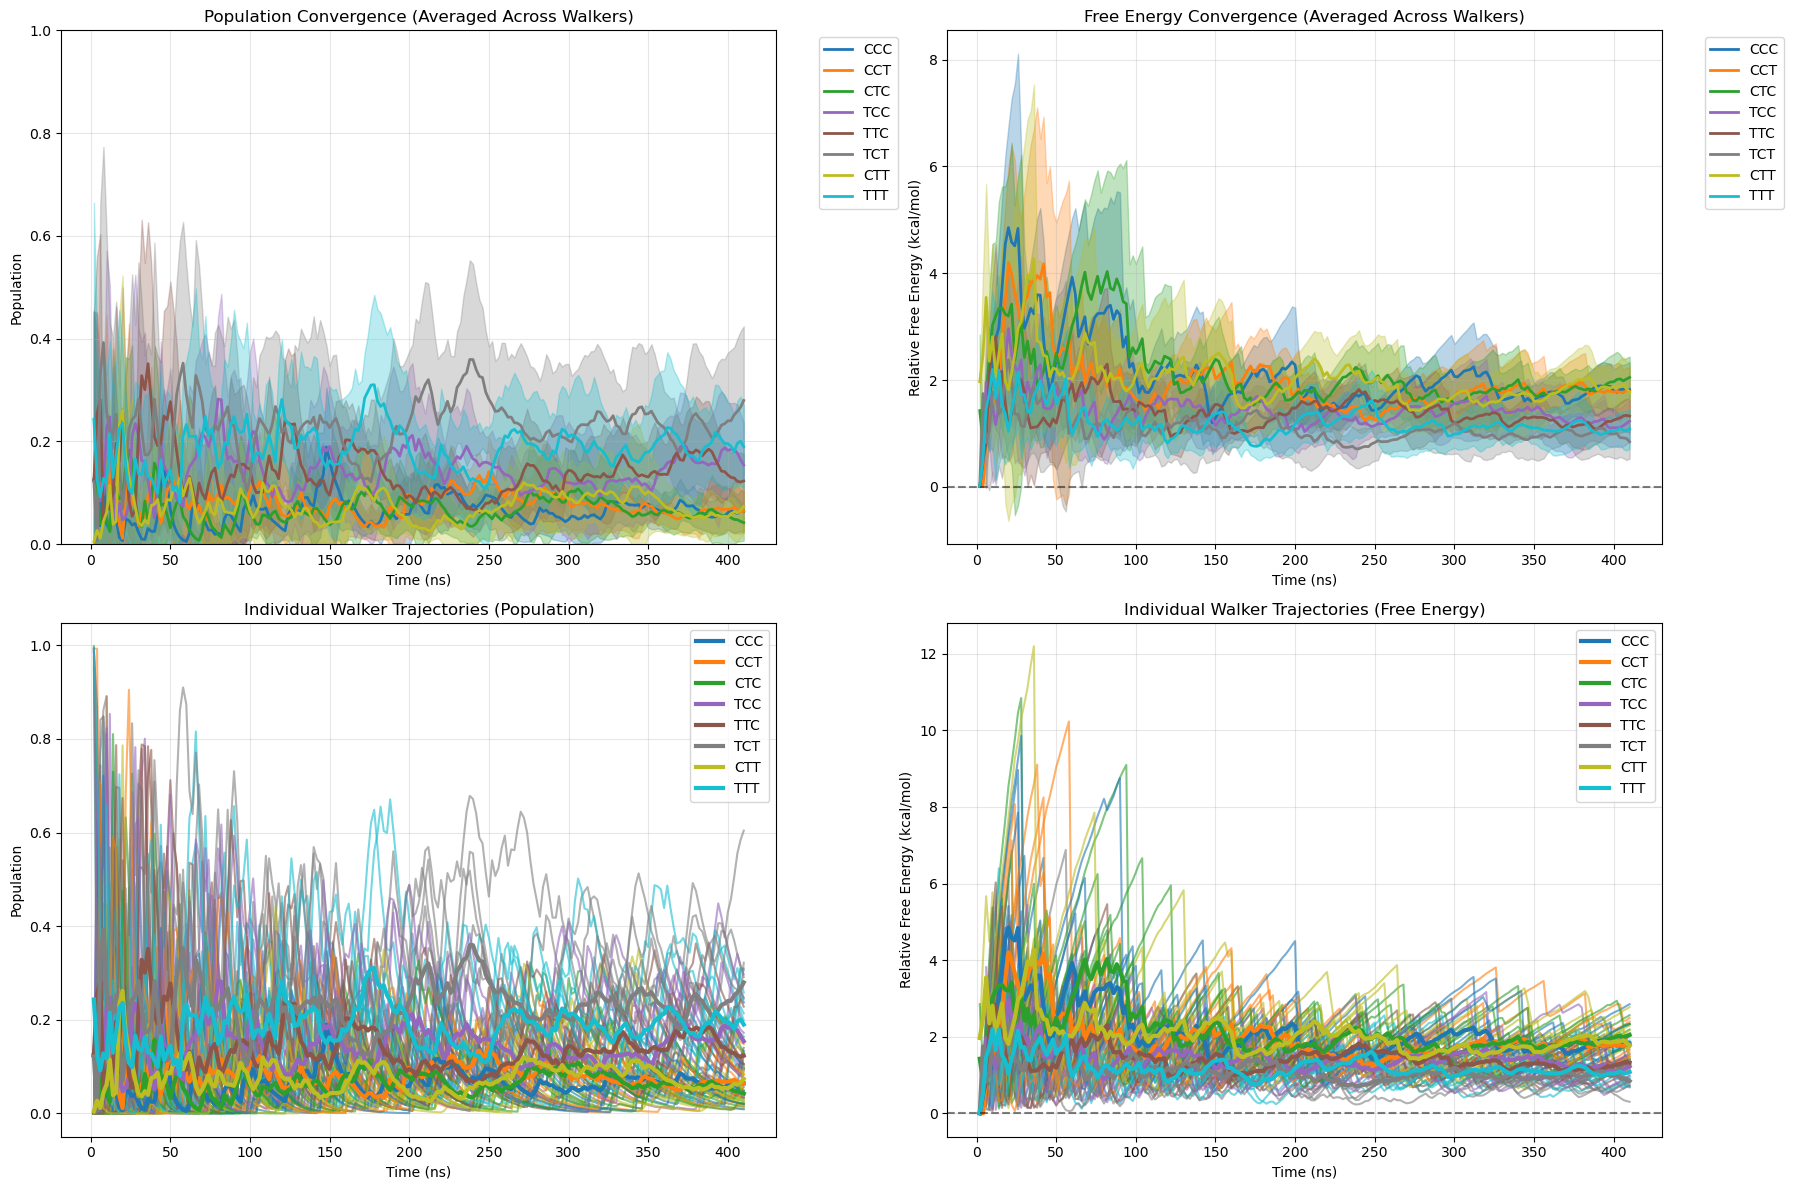

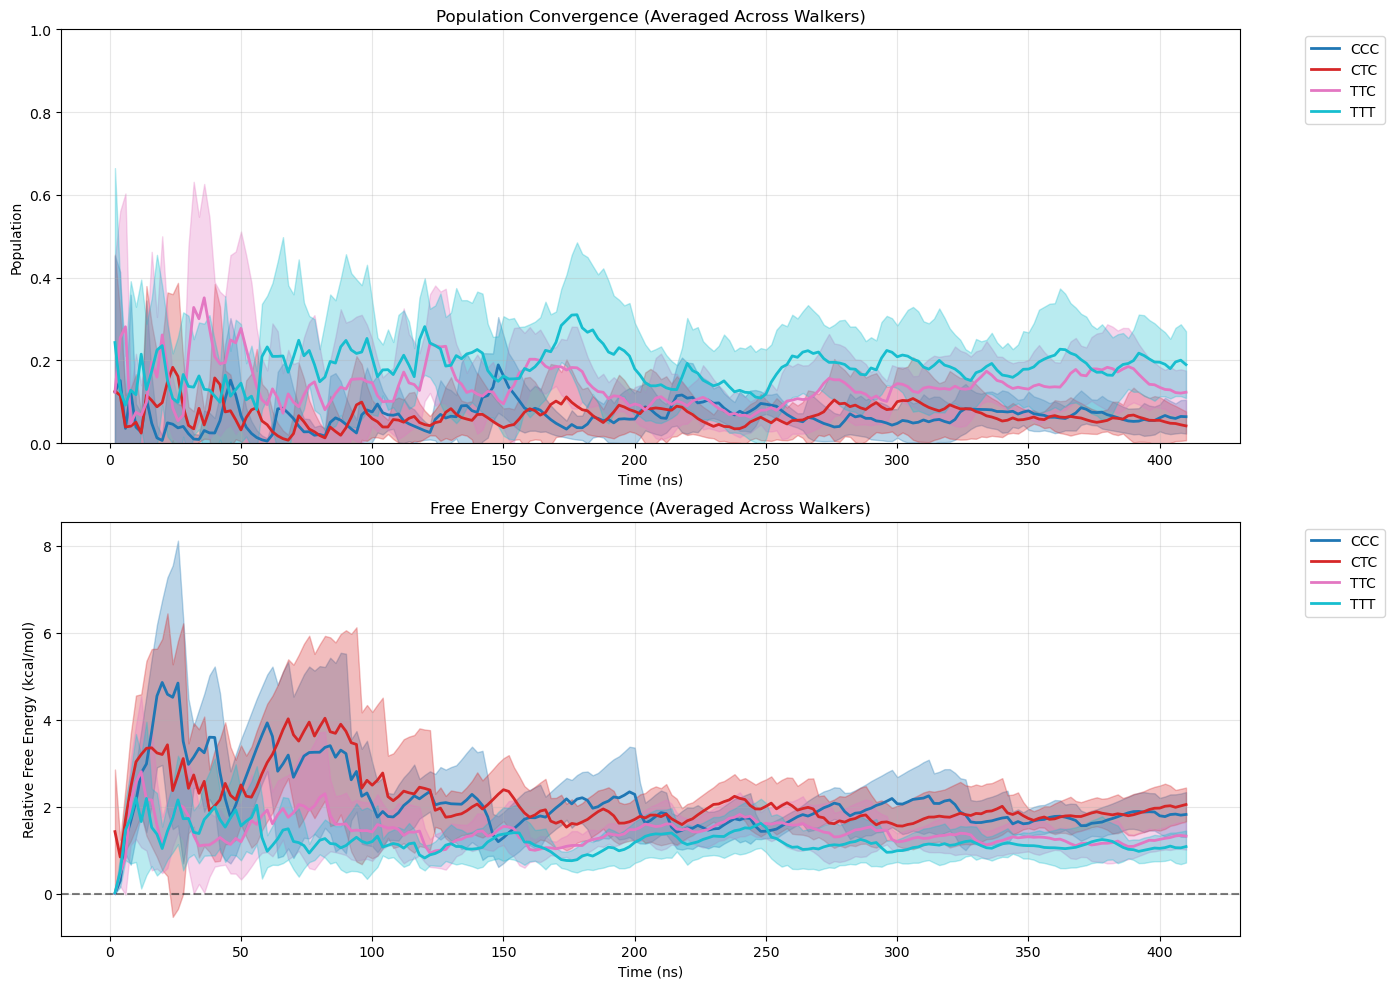

CCC: P = 0.0641 ± 0.0407, ΔG = 1.82 ± 0.51 kcal/mol
CCT: P = 0.0644 ± 0.0407, ΔG = 1.79 ± 0.44 kcal/mol
CTC: P = 0.0419 ± 0.0349, ΔG = 2.05 ± 0.39 kcal/mol
TCC: P = 0.1542 ± 0.0830, ΔG = 1.23 ± 0.39 kcal/mol
TTC: P = 0.1232 ± 0.0523, ΔG = 1.32 ± 0.31 kcal/mol
TCT: P = 0.2797 ± 0.1442, ΔG = 0.84 ± 0.32 kcal/mol
CTT: P = 0.0737 ± 0.0516, ΔG = 1.77 ± 0.55 kcal/mol
TTT: P = 0.1898 ± 0.0807, ΔG = 1.08 ± 0.37 kcal/mol

Reference state (ΔG = 0): TCT


In [10]:
# Later, load and plot
loaded_data = load_convergence_data("convergence_data/8oppc_metadynamics_convergence.pkl")

# Generate standard plots
plot_convergence_from_data(loaded_data)

# Generate plots with individual walker trajectories
plot_convergence_from_data(loaded_data, show_individual_walkers=True)

# Plot only specific states
plot_convergence_from_data(loaded_data, states_to_plot=[1, 3, 5, 8])

# Print final results
print_final_results_from_data(loaded_data)

In [6]:
def load_individual_trajectory(filename):
    """Load a single trajectory from pickle file - no changes needed"""
    with open(filename, 'rb') as f:
        data = pickle.load(f)
    
    print(f"Loaded trajectory: {data['metadata']['trajectory_name']}")
    print(f"  Frame count: {data['metadata']['frame_count']}")
    print(f"  Parameters: {data['metadata']['parameters']}")
    
    return data

def load_trajectory_summary(summary_filename):
    """Load the summary file - simplified since no timestamps"""
    with open(summary_filename, 'rb') as f:
        summary = pickle.load(f)
    
    print("Trajectory Summary:")
    print(f"  Number of trajectories: {summary['metadata']['n_trajectories']}")
    print(f"  Trajectory names: {summary['metadata']['trajectory_names']}")
    print("\nAvailable files:")
    
    for traj_name, filepath in summary['metadata']['trajectory_files'].items():
        print(f"  {traj_name}: {filepath}")
    
    return summary

def load_multiple_trajectories_from_summary(summary_filename):
    """Load all trajectories referenced in summary - simplified"""
    summary = load_trajectory_summary(summary_filename)
    
    loaded_trajectories = {}
    
    for traj_name, filepath in summary['metadata']['trajectory_files'].items():
        try:
            traj_data = load_individual_trajectory(filepath)
            loaded_trajectories[traj_name] = traj_data
        except FileNotFoundError:
            print(f"Warning: Could not load {filepath}")
    
    return loaded_trajectories, summary

def plot_loaded_trajectory(loaded_data, states_to_plot=None):
    """Plot a single loaded trajectory"""
    
    state_labels = loaded_data['metadata']['state_labels']
    conv_data = loaded_data['convergence_data']
    traj_name = loaded_data['metadata']['trajectory_name']
    dt = loaded_data['metadata']['parameters']['dt']
    
    if states_to_plot is None:
        states_to_plot = range(1, 9)
    
    time_ps = [frame * dt for frame in conv_data['frames']]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    colors = plt.cm.tab10(np.linspace(0, 1, len(states_to_plot)))
    
    # Population plot
    for i, state in enumerate(states_to_plot):
        pops = conv_data['populations'][state]
        errors = conv_data['pop_errors'][state]
        
        ax1.plot(time_ps, pops, label=f'{state_labels[state]}', 
                color=colors[i], linewidth=2)
        ax1.fill_between(time_ps, 
                        [p - e if not np.isnan(e) else p for p, e in zip(pops, errors)],
                        [p + e if not np.isnan(e) else p for p, e in zip(pops, errors)],
                        color=colors[i], alpha=0.3)
    
    ax1.set_xlabel('Time (ns)')
    ax1.set_ylabel('Population')
    ax1.set_title(f'{traj_name} - Population Convergence')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1)
    
    # Free energy plot
    for i, state in enumerate(states_to_plot):
        fes = [fe if fe != np.inf else np.nan for fe in conv_data['free_energies'][state]]
        errors = conv_data['fe_errors'][state]
        
        ax2.plot(time_ps, fes, label=f'{state_labels[state]}', 
                color=colors[i], linewidth=2)
        ax2.fill_between(time_ps,
                        [f - e if not np.isnan(e) and not np.isnan(f) else f 
                         for f, e in zip(fes, errors)],
                        [f + e if not np.isnan(e) and not np.isnan(f) else f 
                         for f, e in zip(fes, errors)],
                        color=colors[i], alpha=0.3)
    
    ax2.set_xlabel('Time (ns)')
    ax2.set_ylabel('Relative Free Energy (kcal/mol)')
    ax2.set_title(f'{traj_name} - Free Energy Convergence')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

def plot_loaded_trajectories_comparison(loaded_trajectories, states_to_plot=None):
    """Plot multiple loaded trajectories for comparison"""
    
    if not loaded_trajectories:
        print("No trajectories to plot")
        return
    
    # Get state labels from first trajectory
    first_traj = list(loaded_trajectories.values())[0]
    state_labels = first_traj['metadata']['state_labels']
    dt = first_traj['metadata']['parameters']['dt']
    
    if states_to_plot is None:
        states_to_plot = range(1, 9)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    colors = plt.cm.tab10(np.linspace(0, 1, len(states_to_plot)))
    line_styles = ['-', '--', '-.', ':']
    
    # Population comparison
    for traj_idx, (traj_name, traj_data) in enumerate(loaded_trajectories.items()):
        conv_data = traj_data['convergence_data']
        time_ps = [frame * dt for frame in conv_data['frames']]
        line_style = line_styles[traj_idx % len(line_styles)]
        
        for i, state in enumerate(states_to_plot):
            pops = conv_data['populations'][state]
            label = f'{state_labels[state]}' if traj_idx == 0 else None
            
            ax1.plot(time_ps, pops, color=colors[i], linestyle=line_style,
                    linewidth=2, alpha=0.8, label=label)
    
    ax1.set_xlabel('Time (ns)')
    ax1.set_ylabel('Population')
    ax1.set_title('Population Convergence - All Loaded Trajectories')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1)
    
    # Free energy comparison
    for traj_idx, (traj_name, traj_data) in enumerate(loaded_trajectories.items()):
        conv_data = traj_data['convergence_data']
        time_ps = [frame * dt for frame in conv_data['frames']]
        line_style = line_styles[traj_idx % len(line_styles)]
        
        for i, state in enumerate(states_to_plot):
            fes = [fe if fe != np.inf else np.nan for fe in conv_data['free_energies'][state]]
            label = f'{state_labels[state]}' if traj_idx == 0 else None
            
            ax2.plot(time_ps, fes, color=colors[i], linestyle=line_style,
                    linewidth=2, alpha=0.8, label=label)
    
    ax2.set_xlabel('Time (ns)')
    ax2.set_ylabel('Relative Free Energy (kcal/mol)')
    ax2.set_title('Free Energy Convergence - All Loaded Trajectories')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

In [7]:
# # Method 1: Load individual files directly
# omega_data = load_individual_trajectory("/Volumes/LaCie/STEPs/ConvergenceTest/convergence_data/omega.pkl")
# ophi_data = load_individual_trajectory("/Volumes/LaCie/STEPs/ConvergenceTest/convergence_data/ophi.pkl") 
# opp_data = load_individual_trajectory("/Volumes/LaCie/STEPs/ConvergenceTest/convergence_data/opp.pkl")
# oppc_data = load_individual_trajectory("/Volumes/LaCie/STEPs/ConvergenceTest/convergence_data/oppc.pkl")

# # Plot individual trajectories
# plot_loaded_trajectory(omega_data)
# plot_loaded_trajectory(ophi_data)
# plot_loaded_trajectory(opp_data)
# plot_loaded_trajectory(oppc_data)

# Method 2: Load using summary file
summary = load_trajectory_summary("/Volumes/LaCie/STEPs/ConvergenceTest/convergence_data/trajectory_summary.pkl")

# Load all trajectories at once
all_trajectories, summary = load_multiple_trajectories_from_summary(
    "/Volumes/LaCie/STEPs/ConvergenceTest/convergence_data/trajectory_summary.pkl"
)

# Plot all trajectories for comparison
plot_loaded_trajectories_comparison(all_trajectories)

# Plot specific trajectories
plot_loaded_trajectory(all_trajectories["omega"])
plot_loaded_trajectory(all_trajectories["ophi"])
plot_loaded_trajectory(all_trajectories["opp"])
plot_loaded_trajectory(all_trajectories["oppc"])

# # Method 3: Load specific subset
# omega_data = load_individual_trajectory("/Volumes/LaCie/STEPs/ConvergenceTest/convergence_data/omega.pkl")
# oppc_data = load_individual_trajectory("/Volumes/LaCie/STEPs/ConvergenceTest/convergence_data/oppc.pkl")

# # Create a subset dictionary for comparison
# subset_trajectories = {
#     "omega": omega_data,
#     "oppc": oppc_data
# }

# plot_loaded_trajectories_comparison(subset_trajectories)

# Print final results for all trajectories WITH ERRORS
for traj_name, traj_data in all_trajectories.items():
    print(f"\n=== {traj_name.upper()} Results ===")
    conv_data = traj_data['convergence_data']
    state_labels = traj_data['metadata']['state_labels']
    
    for state in range(1, 9):
        final_pop = conv_data['populations'][state][-1]
        final_pop_err = conv_data['pop_errors'][state][-1]
        final_fe = conv_data['free_energies'][state][-1]
        final_fe_err = conv_data['fe_errors'][state][-1]
        
        if final_fe != np.inf:
            print(f"{state_labels[state]}: P = {final_pop:.4f} ± {final_pop_err:.4f}, "
                  f"ΔG = {final_fe:.2f} ± {final_fe_err:.2f} kcal/mol")
        else:
            print(f"{state_labels[state]}: P = {final_pop:.4f} ± {final_pop_err:.4f}, "
                  f"ΔG = ∞ kcal/mol (not observed)")
    
    # Find and show reference state
    finite_states = {s: conv_data['free_energies'][s][-1] 
                    for s in range(1, 9) 
                    if conv_data['free_energies'][s][-1] != np.inf}
    
    if finite_states:
        ref_state = min(finite_states, key=finite_states.get)
        print(f"Reference state (ΔG = 0): {state_labels[ref_state]}")

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/LaCie/STEPs/ConvergenceTest/convergence_data/trajectory_summary.pkl'

In [ ]:
# Print final results for all trajectories WITH ERRORS
for traj_name, traj_data in all_trajectories.items():
    print(f"\n=== {traj_name.upper()} Results ===")
    conv_data = traj_data['convergence_data']
    state_labels = traj_data['metadata']['state_labels']
    
    for state in range(1, 9):
        final_pop = conv_data['populations'][state][-1]
        final_pop_err = conv_data['pop_errors'][state][-1]
        final_fe = conv_data['free_energies'][state][-1]
        final_fe_err = conv_data['fe_errors'][state][-1]
        
        if final_fe != np.inf:
            print(f"{state_labels[state]}: P = {final_pop:.4f} ± {final_pop_err:.4f}, "
                  f"ΔG = {final_fe:.2f} ± {final_fe_err:.2f} kcal/mol")
        else:
            print(f"{state_labels[state]}: P = {final_pop:.4f} ± {final_pop_err:.4f}, "
                  f"ΔG = ∞ kcal/mol (not observed)")
    
    # Find and show reference state
    finite_states = {s: conv_data['free_energies'][s][-1] 
                    for s in range(1, 9) 
                    if conv_data['free_energies'][s][-1] != np.inf}
    
    if finite_states:
        ref_state = min(finite_states, key=finite_states.get)
        print(f"Reference state (ΔG = 0): {state_labels[ref_state]}")


=== OMEGA Results ===
CCC: P = 0.0744 ± 0.0046, ΔG = 0.65 ± 0.04 kcal/mol
CCT: P = 0.0371 ± 0.0187, ΔG = 1.06 ± 0.30 kcal/mol
CTC: P = 0.0742 ± 0.0036, ΔG = 0.65 ± 0.03 kcal/mol
TCC: P = 0.1381 ± 0.0454, ΔG = 0.27 ± 0.20 kcal/mol
TTC: P = 0.2183 ± 0.0131, ΔG = 0.00 ± 0.04 kcal/mol
TCT: P = 0.1828 ± 0.0130, ΔG = 0.11 ± 0.04 kcal/mol
CTT: P = 0.0922 ± 0.0117, ΔG = 0.52 ± 0.08 kcal/mol
TTT: P = 0.1828 ± 0.0155, ΔG = 0.11 ± 0.05 kcal/mol
Reference state (ΔG = 0): TTC

=== OPHI Results ===
CCC: P = 0.0506 ± 0.0101, ΔG = 0.92 ± 0.12 kcal/mol
CCT: P = 0.0494 ± 0.0120, ΔG = 0.94 ± 0.15 kcal/mol
CTC: P = 0.0632 ± 0.0057, ΔG = 0.79 ± 0.05 kcal/mol
TCC: P = 0.0986 ± 0.0241, ΔG = 0.52 ± 0.15 kcal/mol
TTC: P = 0.2093 ± 0.0175, ΔG = 0.07 ± 0.05 kcal/mol
TCT: P = 0.1890 ± 0.0336, ΔG = 0.13 ± 0.11 kcal/mol
CTT: P = 0.1043 ± 0.0118, ΔG = 0.49 ± 0.07 kcal/mol
TTT: P = 0.2357 ± 0.0341, ΔG = 0.00 ± 0.09 kcal/mol
Reference state (ΔG = 0): TTT

=== OPP Results ===
CCC: P = 0.1147 ± 0.0128, ΔG = 0.58 ± 0.07